In [ ]:
03!pip install albumentations -q

import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import albumentations as A
import kagglehub

In [ ]:
# ── Training Dataset (Big) ─────────────────────────
path_big = kagglehub.dataset_download("zaidpy/oral-cancer-dataset")
print(f"✅ Big dataset: {path_big}")

# ── Test Dataset (Small) ───────────────────────────
path_small = kagglehub.dataset_download(
    "shivam17299/oral-cancer-lips-and-tongue-images")
print(f"✅ Small dataset: {path_small}")

Using Colab cache for faster access to the 'oral-cancer-dataset' dataset.
✅ Big dataset: /kaggle/input/oral-cancer-dataset
Using Colab cache for faster access to the 'oral-cancer-lips-and-tongue-images' dataset.
✅ Small dataset: /kaggle/input/oral-cancer-lips-and-tongue-images


In [ ]:
path_big = '/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2'

datasets = [
    {
        'root': os.path.join(path_big,
                             'Oral cancer Dataset 2.0/OC Dataset kaggle new'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    },
    {
        'root': os.path.join(path_big,
                             'Oral Cancer/Oral Cancer Dataset'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    }
]

filepaths, labels = [], []

for ds in datasets:
    for folder_name, label in ds['subfolders'].items():
        folder_path = os.path.join(ds['root'], folder_name)
        if os.path.exists(folder_path):
            images = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"✅ {len(images)} images — {label}")
            for img in images:
                filepaths.append(os.path.join(folder_path, img))
                labels.append(label)
        else:
            print(f"❌ Not found: {folder_path}")

df_train = pd.DataFrame({'filename': filepaths, 'label': labels})
df_train = df_train.drop_duplicates(subset='filename').reset_index(drop=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Total Training Images : {len(df_train)}")
print(df_train['label'].value_counts())

✅ 500 images — cancer
✅ 450 images — non_cancer
✅ 500 images — cancer
✅ 250 images — non_cancer

📊 Total Training Images : 1700
label
cancer        1000
non_cancer     700
Name: count, dtype: int64


In [ ]:
filepaths_test, labels_test = [], []
label_map_small = {'cancer': 'cancer', 'non-cancer': 'non_cancer'}

for folder_name, label in label_map_small.items():
    folder_path = os.path.join(path_small, 'OralCancer', folder_name)
    if os.path.exists(folder_path):
        images = [f for f in os.listdir(folder_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"✅ {len(images)} images — {label}")
        for img in images:
            filepaths_test.append(os.path.join(folder_path, img))
            labels_test.append(label)
    else:
        print(f"❌ Not found: {folder_path}")

df_test = pd.DataFrame({'filename': filepaths_test, 'label': labels_test})
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Total Test Images : {len(df_test)}")
print(df_test['label'].value_counts())

✅ 87 images — cancer
✅ 44 images — non_cancer

📊 Total Test Images : 131
label
cancer        87
non_cancer    44
Name: count, dtype: int64


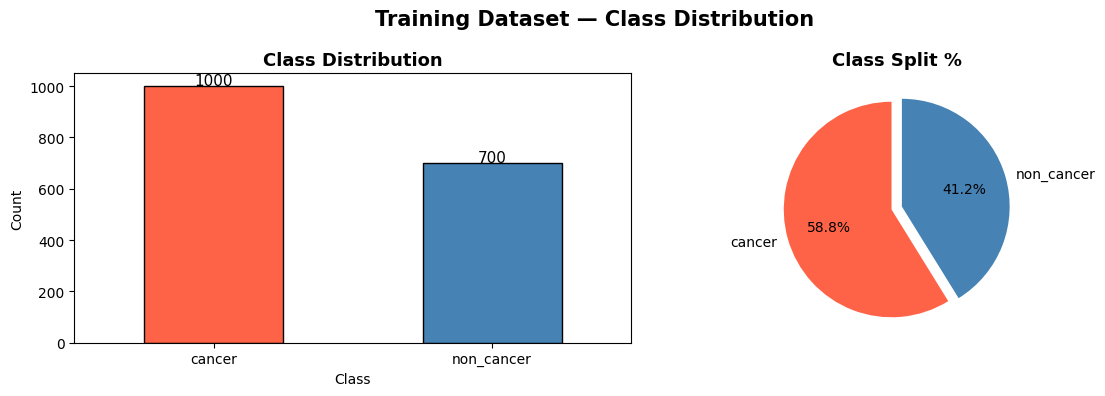


Analyzing image dimensions...


Reading sizes: 100%|██████████| 1700/1700 [00:31<00:00, 53.35it/s]


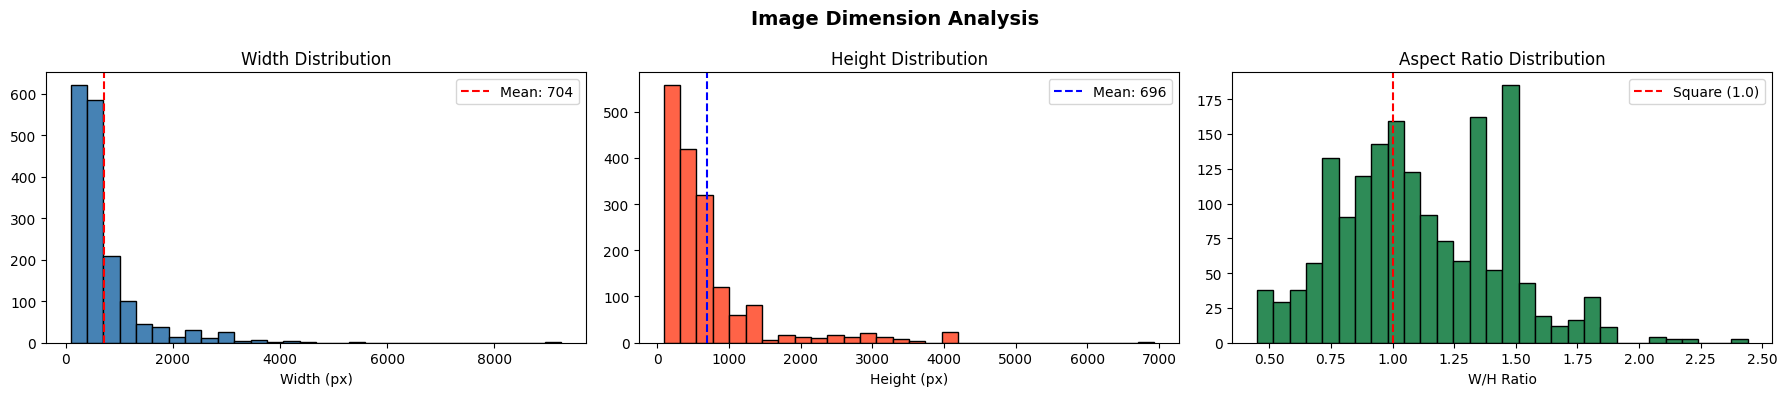

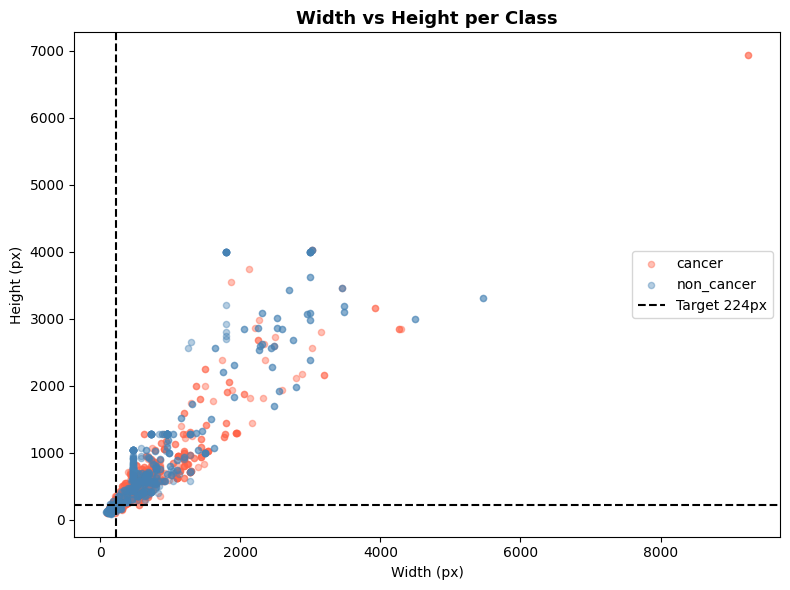

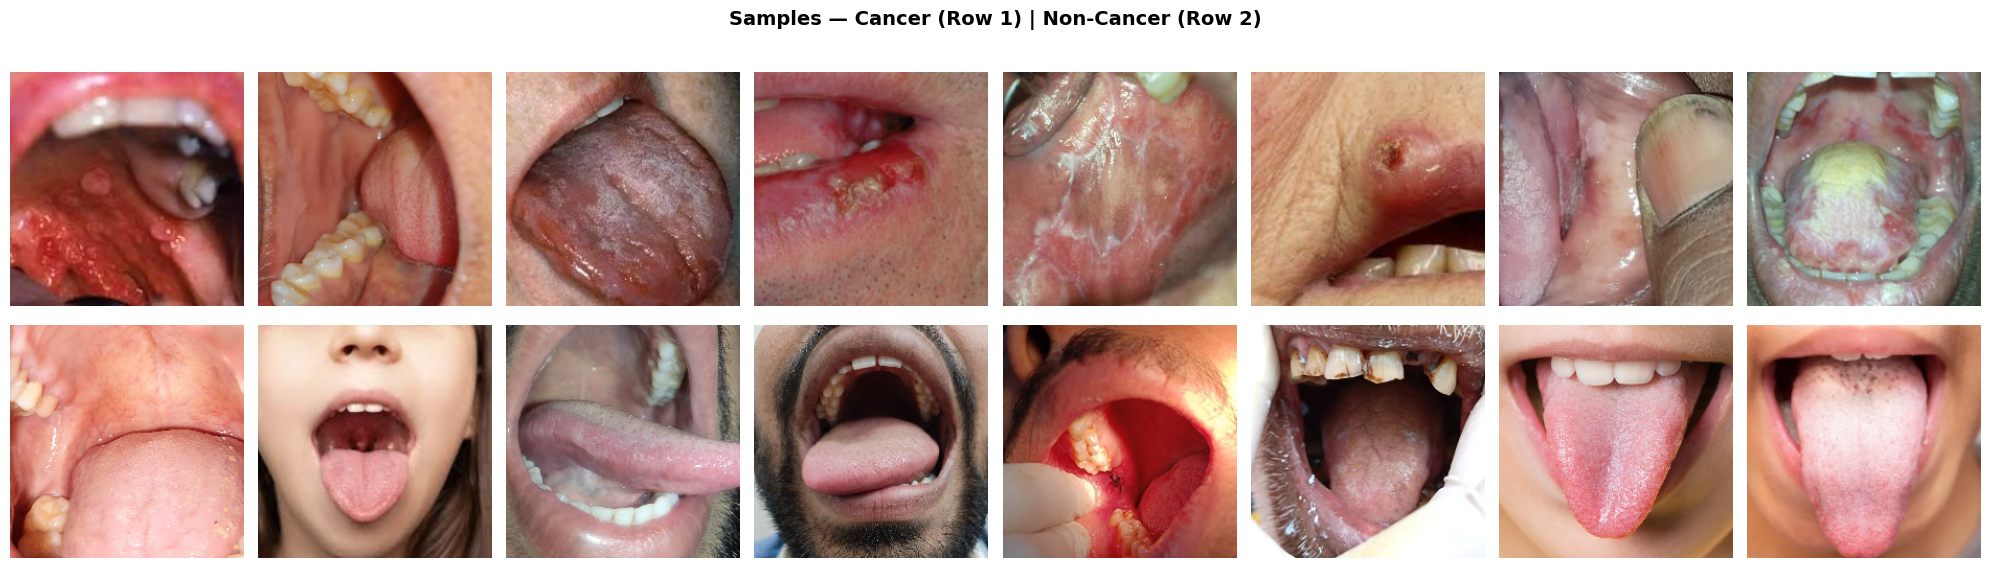

Brightness: 100%|██████████| 1700/1700 [00:24<00:00, 70.23it/s]


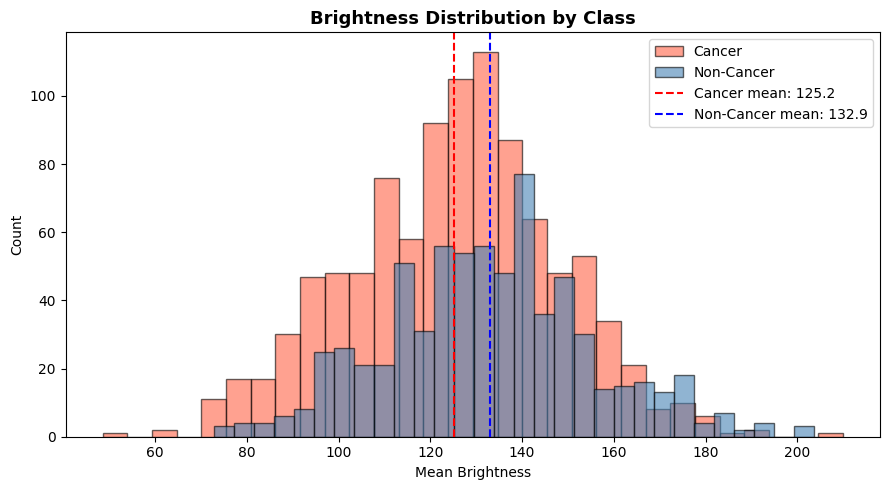


          EDA SUMMARY
  Total          : 1700
  Cancer         : 1000
  Non-Cancer     : 700
  Imbalance      : 1.43x
  Width  range   : 90 — 9248
  Height range   : 89 — 6936
  Uniform size?  : ❌ Resizing needed
  Cancer bright  : 125.2
  NonCancer bright: 132.9


In [ ]:
# ── Class Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['tomato', 'steelblue'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=11)

df_train['label'].value_counts().plot(
    kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['tomato', 'steelblue'],
    startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Split %', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.suptitle('Training Dataset — Class Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Image Size Analysis ────────────────────────────
print("\nAnalyzing image dimensions...")
widths, heights, aspects = [], [], []

for filepath in tqdm(df_train['filename'], desc="Reading sizes"):
    img = cv2.imread(filepath)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        aspects.append(round(w/h, 2))

df_train['width']  = widths
df_train['height'] = heights
df_train['aspect'] = aspects

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df_train['width'], bins=30,
             color='steelblue', edgecolor='black')
axes[0].axvline(df_train['width'].mean(), color='red',
                linestyle='--',
                label=f"Mean: {df_train['width'].mean():.0f}")
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].hist(df_train['height'], bins=30,
             color='tomato', edgecolor='black')
axes[1].axvline(df_train['height'].mean(), color='blue',
                linestyle='--',
                label=f"Mean: {df_train['height'].mean():.0f}")
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

axes[2].hist(df_train['aspect'], bins=30,
             color='seagreen', edgecolor='black')
axes[2].axvline(1.0, color='red', linestyle='--', label='Square (1.0)')
axes[2].set_title('Aspect Ratio Distribution')
axes[2].set_xlabel('W/H Ratio')
axes[2].legend()

plt.suptitle('Image Dimension Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Scatter Plot ───────────────────────────────────
plt.figure(figsize=(8, 6))
for label, color in [('cancer','tomato'), ('non_cancer','steelblue')]:
    s = df_train[df_train['label'] == label]
    plt.scatter(s['width'], s['height'],
                alpha=0.4, color=color, label=label, s=20)
plt.axvline(224, color='black', linestyle='--', label='Target 224px')
plt.axhline(224, color='black', linestyle='--')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.title('Width vs Height per Class', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# ── Sample Images ──────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for row, label in enumerate(['cancer', 'non_cancer']):
    subset = df_train[df_train['label'] == label].sample(8, random_state=42)
    for col, (_, r) in enumerate(subset.iterrows()):
        img = cv2.imread(r['filename'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        m = min(h, w)
        img = img[(h-m)//2:(h-m)//2+m, (w-m)//2:(w-m)//2+m]
        img = cv2.resize(img, (224, 224))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
plt.suptitle('Samples — Cancer (Row 1) | Non-Cancer (Row 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Brightness Analysis ────────────────────────────
bc, bnc = [], []
for _, row in tqdm(df_train.iterrows(), total=len(df_train),
                   desc="Brightness"):
    img = cv2.imread(row['filename'])
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        (bc if row['label'] == 'cancer' else bnc).append(gray.mean())

plt.figure(figsize=(9, 5))
plt.hist(bc,  bins=30, alpha=0.6, color='tomato',
         label='Cancer', edgecolor='black')
plt.hist(bnc, bins=30, alpha=0.6, color='steelblue',
         label='Non-Cancer', edgecolor='black')
plt.axvline(np.mean(bc),  color='red',  linestyle='--',
            label=f'Cancer mean: {np.mean(bc):.1f}')
plt.axvline(np.mean(bnc), color='blue', linestyle='--',
            label=f'Non-Cancer mean: {np.mean(bnc):.1f}')
plt.xlabel('Mean Brightness')
plt.ylabel('Count')
plt.title('Brightness Distribution by Class', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"          EDA SUMMARY")
print(f"{'='*50}")
print(f"  Total          : {len(df_train)}")
print(f"  Cancer         : {sum(df_train['label']=='cancer')}")
print(f"  Non-Cancer     : {sum(df_train['label']=='non_cancer')}")
print(f"  Imbalance      : {df_train['label'].value_counts().max() / df_train['label'].value_counts().min():.2f}x")
print(f"  Width  range   : {df_train['width'].min()} — {df_train['width'].max()}")
print(f"  Height range   : {df_train['height'].min()} — {df_train['height'].max()}")
print(f"  Uniform size?  : ❌ Resizing needed")
print(f"  Cancer bright  : {np.mean(bc):.1f}")
print(f"  NonCancer bright: {np.mean(bnc):.1f}")
print(f"{'='*50}")

In [ ]:
TARGET_SIZE = 224

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2RGB)

def smart_resize(img, target_size=TARGET_SIZE):
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    img_cropped = img[start_h:start_h+min_dim, start_w:start_w+min_dim]
    return cv2.resize(img_cropped, (target_size, target_size))

def sharpen(img):
    gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
    sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def preprocess_image(filepath, target_size=TARGET_SIZE, preprocess_fn=None):
    img = cv2.imread(filepath)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ❌ REMOVED: cv2.fastNlMeansDenoisingColored — too slow
    # ✅ KEPT: CLAHE handles contrast without needing denoise first

    img = apply_clahe(img)      # contrast enhancement
    img = sharpen(img)          # edge sharpening
    img = smart_resize(img, target_size)  # resize
    img = img.astype('float32')
    if preprocess_fn:
        img = preprocess_fn(img)
    return img

def load_display_image(filepath):
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return smart_resize(img)

In [ ]:
print("Preprocessing training images...")
X_all, y_all, valid_paths = [], [], []

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    img = preprocess_image(row['filename'], preprocess_fn=eff_preprocess)
    if img is not None:
        X_all.append(img)
        y_all.append(1 if row['label'] == 'cancer' else 0)
        valid_paths.append(row['filename'])

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"\n✅ Shape       : {X_all.shape}")
print(f"Cancer         : {sum(y_all==1)}")
print(f"Non-Cancer     : {sum(y_all==0)}")
print(f"Pixel range    : [{X_all.min():.1f}, {X_all.max():.1f}]")

Preprocessing training images...


100%|██████████| 1700/1700 [01:22<00:00, 20.68it/s]



✅ Shape       : (1700, 224, 224, 3)
Cancer         : 1000
Non-Cancer     : 700
Pixel range    : [0.0, 255.0]


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Train : {len(X_train)} | Val : {len(X_val)}")
print(f"Train → Cancer: {sum(y_train==1)} | Non-Cancer: {sum(y_train==0)}")
print(f"Val   → Cancer: {sum(y_val==1)}   | Non-Cancer: {sum(y_val==0)}")

Train : 1360 | Val : 340
Train → Cancer: 800 | Non-Cancer: 560
Val   → Cancer: 200   | Non-Cancer: 140


In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# ── Augmentation Transform ─────────────────────────
offline_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10, p=0.4),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GridDistortion(num_steps=5,
                     distort_limit=0.2, p=0.2),
])

# ── Paths ──────────────────────────────────────────
PREPROCESS_DIR = '/content/preprocessed'
AUG_DIR        = '/content/augmented'
TARGET_SIZE    = 224
BATCH_SIZE     = 32

/tmp/ipykernel_11605/2794151421.py:22: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),


In [ ]:
# ── Step 1: Save Preprocessed Images to /content/preprocessed ──
os.makedirs(f'{PREPROCESS_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{PREPROCESS_DIR}/non_cancer', exist_ok=True)

# Check if already done
n_existing = (len(os.listdir(f'{PREPROCESS_DIR}/cancer')) +
              len(os.listdir(f'{PREPROCESS_DIR}/non_cancer')))

if n_existing > 0:
    print(f"✅ Preprocessed images already exist ({n_existing}) — skipping")
else:
    print("Preprocessing and saving to /content/preprocessed ...")

    for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
        img = cv2.imread(row['filename'])
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = apply_clahe(img)
        img = sharpen(img)
        img = smart_resize(img, TARGET_SIZE)

        label     = row['label']   # 'cancer' or 'non_cancer'
        fname     = os.path.splitext(os.path.basename(row['filename']))[0]
        save_path = f'{PREPROCESS_DIR}/{label}/{fname}.jpg'

        cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    n_c  = len(os.listdir(f'{PREPROCESS_DIR}/cancer'))
    n_nc = len(os.listdir(f'{PREPROCESS_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/preprocessed")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")

os.system("du -sh /content/preprocessed")

Preprocessing and saving to /content/preprocessed ...


100%|██████████| 1700/1700 [01:19<00:00, 21.48it/s]


✅ Saved to /content/preprocessed
   cancer     : 500
   non_cancer : 450


0

In [ ]:
# ── Step 2: Train/Val Split from /content/preprocessed ────────
from sklearn.model_selection import train_test_split

# Collect all saved preprocessed paths + labels
all_paths, all_labels = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths.append(os.path.join(folder, fname))
        all_labels.append(label)

all_labels_binary = [1 if l == 'cancer' else 0 for l in all_labels]

train_paths, val_paths, y_train_split, y_val_split = train_test_split(
    all_paths, all_labels_binary,
    test_size=0.2,
    random_state=42,
    stratify=all_labels_binary
)

print(f"Train : {len(train_paths)} | Val : {len(val_paths)}")
print(f"Train → Cancer: {sum(y_train_split==np.array(1))} | "
      f"Non-Cancer: {sum(np.array(y_train_split)==0)}")

Train : 760 | Val : 190
Train → Cancer: 400 | Non-Cancer: 360


In [ ]:
# ── Step 3: Offline Augment TRAIN only → /content/augmented ───
os.makedirs(f'{AUG_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{AUG_DIR}/non_cancer', exist_ok=True)

n_existing_aug = (len(os.listdir(f'{AUG_DIR}/cancer')) +
                  len(os.listdir(f'{AUG_DIR}/non_cancer')))

if n_existing_aug > 0:
    print(f"✅ Augmented images already exist ({n_existing_aug}) — skipping")
else:
    N_COPIES = 4
    print(f"Augmenting train set × {N_COPIES} → /content/augmented ...")
    print(f"Original: {len(train_paths)} → "
          f"Target  : {len(train_paths) * (N_COPIES+1)}")

    for idx, (fpath, label_int) in enumerate(
            tqdm(zip(train_paths, y_train_split),
                 total=len(train_paths))):

        label = 'cancer' if label_int == 1 else 'non_cancer'

        # Read preprocessed image from /content/preprocessed
        img = cv2.imread(fpath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        fname_base = os.path.splitext(os.path.basename(fpath))[0]

        # ── Save original copy ─────────────────────
        cv2.imwrite(
            f'{AUG_DIR}/{label}/orig_{fname_base}.jpg',
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )

        # ── Save N augmented copies ────────────────
        for c in range(N_COPIES):
            augmented = offline_transform(image=img)['image']
            cv2.imwrite(
                f'{AUG_DIR}/{label}/aug{c}_{fname_base}.jpg',
                cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
            )
            # ✅ each augmented image discarded immediately — RAM safe

    n_c  = len(os.listdir(f'{AUG_DIR}/cancer'))
    n_nc = len(os.listdir(f'{AUG_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/augmented")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")
    print(f"   total      : {n_c + n_nc}")

os.system("du -sh /content/augmented")

Augmenting train set × 4 → /content/augmented ...
Original: 760 → Target  : 3800


100%|██████████| 760/760 [00:10<00:00, 74.32it/s]


✅ Saved to /content/augmented
   cancer     : 2000
   non_cancer : 1800
   total      : 3800


0

In [ ]:
# ── Step 4: Load Val Set into RAM (small — safe) ───────────────
print("Loading val set into RAM...")
X_val, y_val = [], []

for fpath, label_int in tqdm(zip(val_paths, y_val_split),
                              total=len(val_paths)):
    img = cv2.imread(fpath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = eff_preprocess(img)
    X_val.append(img)
    y_val.append(label_int)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"✅ Val shape : {X_val.shape}")
print(f"   Cancer   : {sum(y_val==1)}")
print(f"   NonCancer: {sum(y_val==0)}")

Loading val set into RAM...


100%|██████████| 190/190 [00:00<00:00, 1058.85it/s]


✅ Val shape : (190, 224, 224, 3)
   Cancer   : 100
   NonCancer: 90


In [ ]:
# ── Step 5: Generators ─────────────────────────────────────────
# Train → flow_from_directory (disk, RAM safe)
# Val   → flow from RAM array (only 340 images)

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=eff_preprocess  # normalize per batch ✅
)

val_datagen = ImageDataGenerator()         # no augmentation on val

train_gen = train_datagen.flow_from_directory(
    AUG_DIR,                               # /content/augmented
    target_size=(TARGET_SIZE, TARGET_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_cancer', 'cancer'],      # 0=non_cancer, 1=cancer
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n✅ Train generator ready")
print(f"   Samples : {train_gen.samples}")
print(f"   Batches : {len(train_gen)}")
print(f"   Classes : {train_gen.class_indices}")
# Must print: {'non_cancer': 0, 'cancer': 1}

print(f"\n✅ Val generator ready")
print(f"   Samples : {len(X_val)}")

Found 3800 images belonging to 2 classes.

✅ Train generator ready
   Samples : 3800
   Batches : 119
   Classes : {'non_cancer': 0, 'cancer': 1}

✅ Val generator ready
   Samples : 190


In [ ]:
# ── Step 6: Class Weights ──────────────────────────────────────
n_cancer    = len(os.listdir(f'{AUG_DIR}/cancer'))
n_noncancer = len(os.listdir(f'{AUG_DIR}/non_cancer'))
total_aug   = n_cancer + n_noncancer

class_weight_dict = {
    0: total_aug / (2 * n_noncancer),
    1: total_aug / (2 * n_cancer)
}
print(f"Class weights : {class_weight_dict}")

Class weights : {0: 1.0555555555555556, 1: 0.95}


In [ ]:
def build_efficientnet(input_shape=(TARGET_SIZE, TARGET_SIZE, 3)):
    base_model = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

eff_model, eff_base = build_efficientnet()
print(f"Total params: {eff_model.count_params():,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params: 4,226,980


In [ ]:
class CombinedMetricCallback(tf.keras.callbacks.Callback):

    def __init__(self, patience=12, model_name='model'):
        super().__init__()
        self.patience     = patience
        self.model_name   = model_name
        self.best_score   = 0
        self.wait         = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        auc      = logs.get('val_auc', 0)
        acc      = logs.get('val_accuracy', 0)
        combined = 0.6 * auc + 0.4 * acc

        print(f"\n  📊 val_auc: {auc:.4f} | val_acc: {acc:.4f} "
              f"| combined: {combined:.4f} (best: {self.best_score:.4f})")

        if combined > self.best_score + 0.001:
            print(f"  ✅ Improved → saving model")
            self.best_score   = combined
            self.wait         = 0
            self.best_weights = self.model.get_weights()
            self.model.save(f'best_{self.model_name}.keras')
        else:
            self.wait += 1
            print(f"  ⏳ No improvement. "
                  f"Patience: {self.wait}/{self.patience}")
            if self.wait >= self.patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights:
            self.model.set_weights(self.best_weights)
            print(f"\n✅ Best weights restored "
                  f"(combined score: {self.best_score:.4f})")

def get_callbacks(model_name):
    return [
        CombinedMetricCallback(patience=12, model_name=model_name),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1)
    ]

def compile_model(model, lr):
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

In [ ]:
print("="*50)
print("Phase 1 — Training head only (base frozen)")
print("="*50)

compile_model(eff_model, lr=1e-3)

history1 = eff_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('EfficientNetB0'),
    verbose=1
)

Phase 1 — Training head only (base frozen)
Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7192 - auc: 0.7920 - loss: 0.6023 - precision: 0.7481 - recall: 0.6860
  📊 val_auc: 0.9807 | val_acc: 0.9316 | combined: 0.9611 (best: 0.0000)
  ✅ Improved → saving model
119/119 ━━━━━━━━━━━━━━━━━━━━ 119s 722ms/step - accuracy: 0.7795 - auc: 0.8636 - loss: 0.4857 - precision: 0.8007 - recall: 0.7735 - val_accuracy: 0.9316 - val_auc: 0.9807 - val_loss: 0.2617 - val_precision: 0.9579 - val_recall: 0.9100 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8623 - auc: 0.9317 - loss: 0.3384 - precision: 0.8799 - recall: 0.8607
  📊 val_auc: 0.9809 | val_acc: 0.9053 | combined: 0.9506 (best: 0.9611)
  ⏳ No improvement. Patience: 1/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 45s 375ms/step - accuracy: 0.8576 - auc: 0.9320 - loss: 0.3389 - precision: 0.8660 - recall: 0.8630 - val_accuracy: 0.9053 - val_auc: 0.9809 - val_loss: 0.2225 - val_precision: 0.9100 

In [ ]:
print("="*50)
print("Phase 2 — Fine tuning top 20 layers")
print("="*50)

eff_base.trainable = True
for layer in eff_base.layers[:-20]:
    layer.trainable = False

compile_model(eff_model, lr=1e-5)

history2 = eff_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('EfficientNetB0'),
    verbose=1
)

Phase 2 — Fine tuning top 20 layers
Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.8415 - auc: 0.9295 - loss: 0.3440 - precision: 0.8697 - recall: 0.8255
  📊 val_auc: 0.9887 | val_acc: 0.9474 | combined: 0.9722 (best: 0.0000)
  ✅ Improved → saving model
119/119 ━━━━━━━━━━━━━━━━━━━━ 104s 627ms/step - accuracy: 0.8521 - auc: 0.9330 - loss: 0.3321 - precision: 0.8733 - recall: 0.8410 - val_accuracy: 0.9474 - val_auc: 0.9887 - val_loss: 0.1576 - val_precision: 0.9787 - val_recall: 0.9200 - learning_rate: 1.0000e-05
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8602 - auc: 0.9418 - loss: 0.3092 - precision: 0.8770 - recall: 0.8500
  📊 val_auc: 0.9819 | val_acc: 0.9316 | combined: 0.9618 (best: 0.9722)
  ⏳ No improvement. Patience: 1/12
119/119 ━━━━━━━━━━━━━━━━━━━━ 45s 380ms/step - accuracy: 0.8647 - auc: 0.9429 - loss: 0.3062 - precision: 0.8814 - recall: 0.8585 - val_accuracy: 0.9316 - val_auc: 0.9819 - val_loss: 0.1817 - val_precision: 0.9579 - v

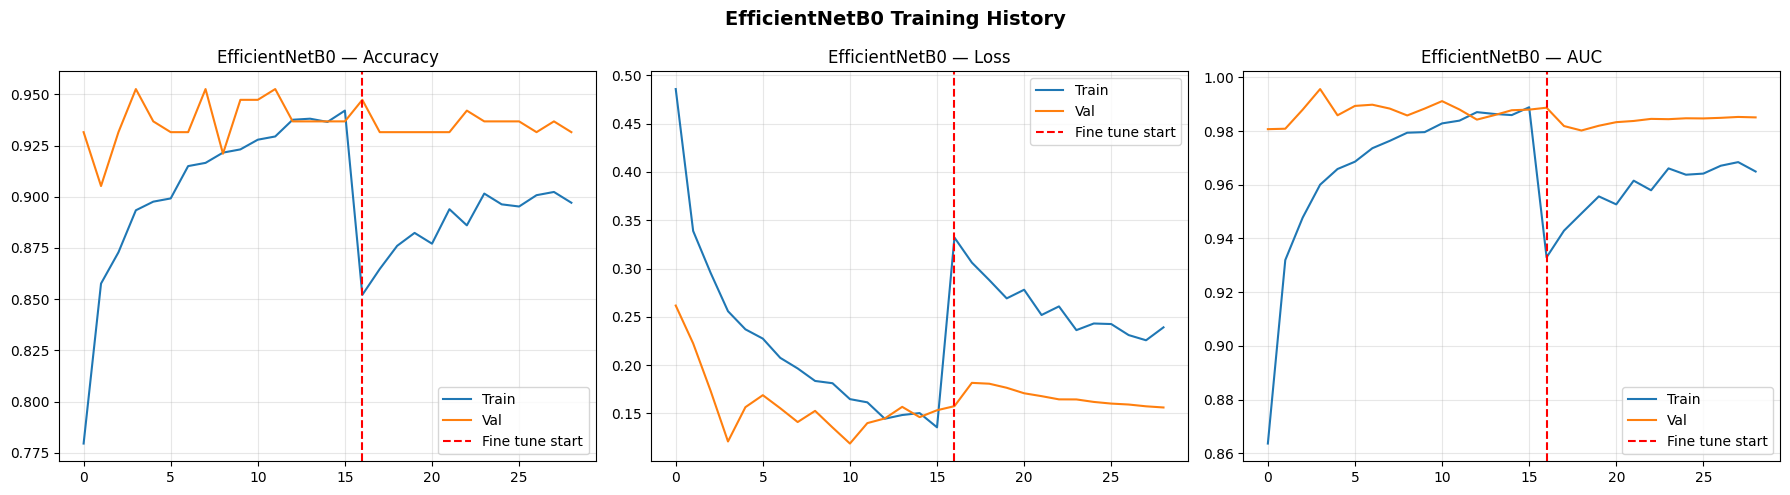

In [ ]:
def plot_history(h1, h2, model_name):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    auc      = h1.history['auc']          + h2.history['auc']
    val_auc  = h1.history['val_auc']      + h2.history['val_auc']
    split    = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tr, vl, title in zip(
        axes,
        [acc,     loss,     auc],
        [val_acc, val_loss, val_auc],
        ['Accuracy', 'Loss', 'AUC']
    ):
        ax.plot(tr, label='Train')
        ax.plot(vl, label='Val')
        ax.axvline(x=split, color='r',
                   linestyle='--', label='Fine tune start')
        ax.set_title(f'{model_name} — {title}', fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(f'{model_name} Training History',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150)
    plt.show()

plot_history(history1, history2, 'EfficientNetB0')

In [ ]:
print("Preprocessing test images...")
X_test, y_test, test_paths = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    img = preprocess_image(row['filename'], preprocess_fn=eff_preprocess)
    if img is not None:
        X_test.append(img)
        y_test.append(1 if row['label'] == 'cancer' else 0)
        test_paths.append(row['filename'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"✅ Test shape   : {X_test.shape}")
print(f"Cancer          : {sum(y_test==1)}")
print(f"Non-Cancer      : {sum(y_test==0)}")

Preprocessing test images...


100%|██████████| 131/131 [00:06<00:00, 21.54it/s]


✅ Test shape   : (131, 224, 224, 3)
Cancer          : 87
Non-Cancer      : 44


5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step

AUC Score         : 0.8977
Optimal Threshold : 0.2706

── Default Threshold (0.50) ──
              precision    recall  f1-score   support

  Non-Cancer       0.72      0.89      0.80        44
      Cancer       0.94      0.83      0.88        87

    accuracy                           0.85       131
   macro avg       0.83      0.86      0.84       131
weighted avg       0.86      0.85      0.85       131


── Optimal Threshold (0.27) ──
              precision    recall  f1-score   support

  Non-Cancer       0.79      0.86      0.83        44
      Cancer       0.93      0.89      0.91        87

    accuracy                           0.88       131
   macro avg       0.86      0.87      0.87       131
weighted avg       0.88      0.88      0.88       131



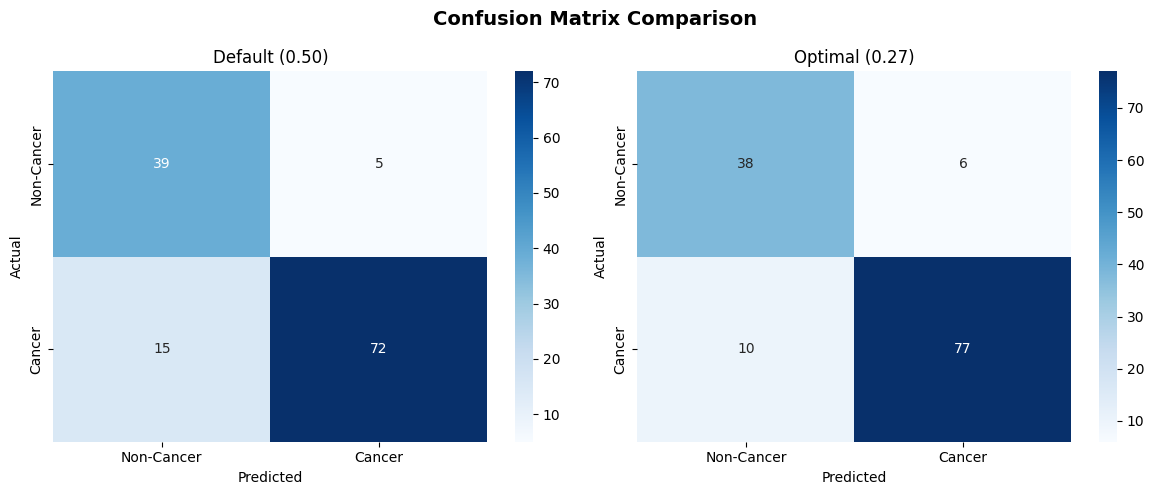

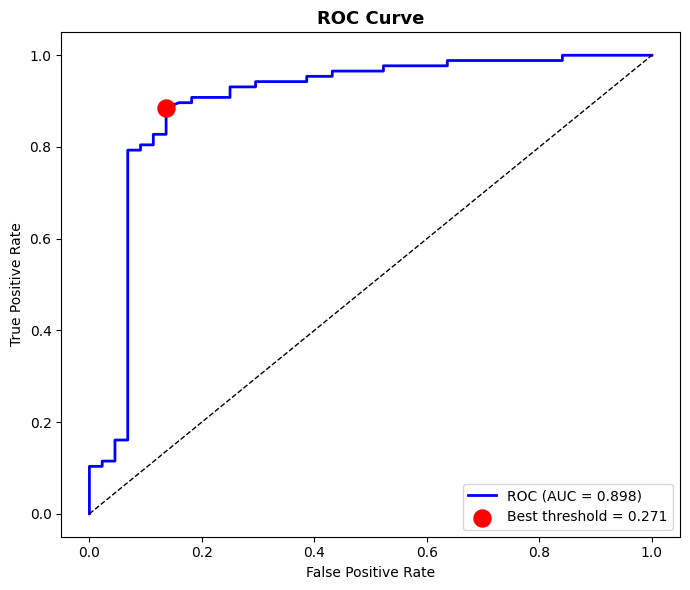

In [ ]:
# Load best saved model
eff_model = tf.keras.models.load_model(
    'best_EfficientNetB0.keras',
    custom_objects={'CombinedMetricCallback': CombinedMetricCallback}
)

y_pred_prob = eff_model.predict(X_test, verbose=1).flatten()

# ROC + optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score  = roc_auc_score(y_test, y_pred_prob)
best_idx   = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]

y_pred_default = (y_pred_prob >= 0.50).astype(int)
y_pred_optimal = (y_pred_prob >= best_thresh).astype(int)

print(f"\nAUC Score         : {auc_score:.4f}")
print(f"Optimal Threshold : {best_thresh:.4f}")

for preds, label in [
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({best_thresh:.2f})')
]:
    print(f"\n── {label} ──")
    print(classification_report(y_test, preds,
          target_names=['Non-Cancer', 'Cancer']))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    ['Default (0.50)', f'Optimal ({best_thresh:.2f})']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Cancer', 'Cancer'],
                yticklabels=['Non-Cancer', 'Cancer'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC (AUC = {auc_score:.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red',
            s=150, zorder=5,
            label=f'Best threshold = {best_thresh:.3f}')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def apply_gradcam_overlay(img_display, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(
        heatmap, (img_display.shape[1], img_display.shape[0]))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_display, 1-alpha, heatmap_colored, alpha, 0)
    return overlay, heatmap_resized

def draw_cancer_region(img, heatmap_resized, threshold=0.5):
    img_annotated = img.copy()
    hot_mask = (heatmap_resized >= threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(
        hot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        if len(largest) >= 5:
            ellipse = cv2.fitEllipse(largest)
            cv2.ellipse(img_annotated, ellipse, (255, 0, 0), 3)
            cx, cy = int(ellipse[0][0]), int(ellipse[0][1])
            label_y = max(cy - int(ellipse[1][1]/2) - 10, 20)
            cv2.putText(img_annotated, 'Suspected Region',
                        (cx-70, label_y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        else:
            x, y, w, h = cv2.boundingRect(largest)
            cv2.rectangle(img_annotated, (x,y), (x+w,y+h), (255,0,0), 3)
    return img_annotated

last_conv = find_last_conv_layer(eff_model)
n = len(X_test)
fig, axes = plt.subplots(n, 4, figsize=(20, n * 5))

for i in tqdm(range(n), desc="Generating GradCAM"):
    actual    = 'Cancer'     if y_test[i] == 1       else 'Non-Cancer'
    predicted = 'Cancer'     if y_pred_optimal[i]==1 else 'Non-Cancer'
    prob      = y_pred_prob[i]
    correct   = y_test[i]    == y_pred_optimal[i]
    status    = '✅ CORRECT' if correct              else '❌ WRONG'

    img_display = load_display_image(test_paths[i])
    img_array   = np.expand_dims(X_test[i], axis=0)
    heatmap     = get_gradcam_heatmap(eff_model, img_array, last_conv)
    overlay, heatmap_resized = apply_gradcam_overlay(img_display, heatmap)
    annotated   = draw_cancer_region(overlay, heatmap_resized)

    # Col 1 — Original
    axes[i][0].imshow(img_display)
    axes[i][0].set_title(f'Actual: {actual}',
                          fontsize=9, fontweight='bold')
    axes[i][0].axis('off')

    # Col 2 — GradCAM
    axes[i][1].imshow(overlay)
    axes[i][1].set_title('GradCAM', fontsize=9)
    axes[i][1].axis('off')

    # Col 3 — Annotated
    axes[i][2].imshow(annotated)
    axes[i][2].set_title('Suspected Region', fontsize=9)
    axes[i][2].axis('off')

    # Col 4 — Result card
    bg = (200,255,200) if correct else (255,200,200)
    result_img = np.ones((224,224,3), dtype=np.uint8)
    result_img[:] = bg
    axes[i][3].imshow(result_img)
    axes[i][3].text(0.5, 0.65, status,
                     transform=axes[i][3].transAxes,
                     ha='center', fontsize=12, fontweight='bold',
                     color='green' if correct else 'red')
    axes[i][3].text(0.5, 0.50, f'Actual: {actual}',
                     transform=axes[i][3].transAxes,
                     ha='center', fontsize=10)
    axes[i][3].text(0.5, 0.38, f'Pred: {predicted}',
                     transform=axes[i][3].transAxes,
                     ha='center', fontsize=10,
                     color='green' if correct else 'red')
    axes[i][3].text(0.5, 0.26, f'Prob: {prob*100:.1f}%',
                     transform=axes[i][3].transAxes,
                     ha='center', fontsize=10)
    axes[i][3].axis('off')

plt.suptitle('All Test Images — Actual vs Predicted vs GradCAM',
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('final_results.png', dpi=80, bbox_inches='tight')
plt.show()

In [ ]:
total   = len(y_test)
correct = sum(y_test == y_pred_optimal)
acc     = correct / total * 100
fn      = sum((y_pred_optimal==0) & (y_test==1))
fp      = sum((y_pred_optimal==1) & (y_test==0))

print(f"\n{'='*55}")
print(f"         FINAL RESULTS SUMMARY")
print(f"{'='*55}")
print(f"  Train images     : {len(X_train_aug)} (after augmentation)")
print(f"  Test images      : {total} (unseen small dataset)")
print(f"  ─────────────────────────────────────────────")
print(f"  AUC Score        : {auc_score:.4f}")
print(f"  Accuracy         : {acc:.1f}%")
print(f"  Correct          : {correct}/{total}")
print(f"  ─────────────────────────────────────────────")
print(f"  Cancer Recall    : "
      f"{sum((y_pred_optimal==1)&(y_test==1))}/{sum(y_test==1)}")
print(f"  NonCancer Recall : "
      f"{sum((y_pred_optimal==0)&(y_test==0))}/{sum(y_test==0)}")
print(f"  ─────────────────────────────────────────────")
print(f"  False Negatives  : {fn} ← missed cancers ⚠️")
print(f"  False Positives  : {fp} ← false alarms")
print(f"{'='*55}")



         FINAL RESULTS SUMMARY


NameError: name 'X_train_aug' is not defined

In [ ]:
for folder in [PREPROCESS_DIR, AUG_DIR]:
    print(f"\n📁 {folder}")
    if os.path.exists(folder):
        for subfolder in sorted(os.listdir(folder)):
            sub_path = os.path.join(folder, subfolder)
            if os.path.isdir(sub_path):
                count = len(os.listdir(sub_path))
                print(f"   └── {subfolder:15s} → {count} images")
    else:
        print("   ❌ Does not exist")


📁 /content/preprocessed
   └── cancer          → 500 images
   └── non_cancer      → 450 images

📁 /content/augmented
   └── cancer          → 2000 images
   └── non_cancer      → 1800 images


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# ══════════════════════════════════════════════════
#   ✏️  ONLY CHANGE THESE
# ══════════════════════════════════════════════════
MODEL_PATH  = '/content/best_EfficientNetB0.keras'
TARGET_SIZE = 224
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2    # same split used during training
RANDOM_SEED = 42
# ══════════════════════════════════════════════════

In [ ]:
# ── Rebuild val split directly from kaggle cache ──
# No /content/ needed — reads straight from source

path_big = '/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2'

datasets = [
    {
        'root': os.path.join(path_big,
                 'Oral cancer Dataset 2.0/OC Dataset kaggle new'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    },
    {
        'root': os.path.join(path_big,
                 'Oral Cancer/Oral Cancer Dataset'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    }
]

filepaths, labels = [], []

for ds in datasets:
    for folder_name, label in ds['subfolders'].items():
        folder_path = os.path.join(ds['root'], folder_name)
        if os.path.exists(folder_path):
            images = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png','.jpg','.jpeg'))]
            print(f"✅ {len(images)} — {label}")
            for img in images:
                filepaths.append(os.path.join(folder_path, img))
                labels.append(label)
        else:
            print(f"❌ Not found: {folder_path}")

# Convert to binary
all_labels_binary = [1 if l == 'cancer' else 0 for l in labels]

# ── Same split as training (same seed = same val set) ──
train_paths, val_paths, y_train, y_val = train_test_split(
    filepaths, all_labels_binary,
    test_size=VAL_SPLIT,
    random_state=RANDOM_SEED,
    stratify=all_labels_binary
)

print(f"\n📊 Reconstructed split:")
print(f"   Train : {len(train_paths)}")
print(f"   Val   : {len(val_paths)}")
print(f"   Val Cancer    : {sum(np.array(y_val)==1)}")
print(f"   Val NonCancer : {sum(np.array(y_val)==0)}")

✅ 500 — cancer
✅ 450 — non_cancer
✅ 500 — cancer
✅ 250 — non_cancer

📊 Reconstructed split:
   Train : 1360
   Val   : 340
   Val Cancer    : 200
   Val NonCancer : 140


In [ ]:
# ── Preprocessing ──────────────────────────────────
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]),
                        cv2.COLOR_LAB2RGB)

def smart_resize(img, target_size=TARGET_SIZE):
    h, w = img.shape[:2]
    min_dim = min(h, w)
    sh = (h - min_dim) // 2
    sw = (w - min_dim) // 2
    return cv2.resize(
        img[sh:sh+min_dim, sw:sw+min_dim],
        (target_size, target_size))

def sharpen(img):
    gaussian  = cv2.GaussianBlur(img, (0, 0), 2.0)
    sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def preprocess_for_pred(filepath):
    img = cv2.imread(filepath)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_clahe(img)
    img = sharpen(img)
    img = smart_resize(img)
    img = img.astype('float32')
    img = eff_preprocess(img)
    return img

print("✅ Preprocessing functions ready")

✅ Preprocessing functions ready


In [ ]:
# ── Preprocess Val Set ─────────────────────────────
print("Preprocessing val images...")

X_val_final, y_val_final, val_paths_final = [], [], []
skipped = 0

for fpath, label_int in tqdm(zip(val_paths, y_val),
                               total=len(val_paths)):
    img = preprocess_for_pred(fpath)
    if img is None:
        skipped += 1
        continue
    X_val_final.append(img)
    y_val_final.append(label_int)
    val_paths_final.append(fpath)

X_val_final = np.array(X_val_final)
y_val_final = np.array(y_val_final)

print(f"\n✅ Val shape  : {X_val_final.shape}")
print(f"   Cancer    : {sum(y_val_final==1)}")
print(f"   NonCancer : {sum(y_val_final==0)}")
print(f"   Skipped   : {skipped}")

Preprocessing val images...


100%|██████████| 340/340 [00:15<00:00, 22.03it/s]


✅ Val shape  : (340, 224, 224, 3)
   Cancer    : 200
   NonCancer : 140
   Skipped   : 0


In [ ]:
# ── Load Model ─────────────────────────────────────
model = tf.keras.models.load_model(MODEL_PATH)
print(f"✅ Model loaded from {MODEL_PATH}")

✅ Model loaded from /content/best_EfficientNetB0.keras


In [ ]:
# ── Predict ────────────────────────────────────────
print("Running predictions...")
y_pred_prob = model.predict(
    X_val_final, batch_size=BATCH_SIZE, verbose=1).flatten()

# Optimal threshold
fpr, tpr, thresholds = roc_curve(y_val_final, y_pred_prob)
auc_score   = roc_auc_score(y_val_final, y_pred_prob)
best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]

y_pred_default = (y_pred_prob >= 0.50).astype(int)
y_pred_optimal = (y_pred_prob >= best_thresh).astype(int)

print(f"\n✅ AUC Score         : {auc_score:.4f}")
print(f"   Optimal threshold : {best_thresh:.4f}")

Running predictions...
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step

✅ AUC Score         : 0.9905
   Optimal threshold : 0.2172


In [ ]:
# ── Classification Reports ─────────────────────────
for preds, label in [
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({best_thresh:.2f})')
]:
    print(f"\n── {label} ──")
    print(classification_report(
        y_val_final, preds,
        target_names=['Non-Cancer', 'Cancer']))


── Default Threshold (0.50) ──
              precision    recall  f1-score   support

  Non-Cancer       0.87      0.97      0.92       140
      Cancer       0.98      0.90      0.94       200

    accuracy                           0.93       340
   macro avg       0.93      0.94      0.93       340
weighted avg       0.93      0.93      0.93       340


── Optimal Threshold (0.22) ──
              precision    recall  f1-score   support

  Non-Cancer       0.95      0.94      0.95       140
      Cancer       0.96      0.96      0.96       200

    accuracy                           0.96       340
   macro avg       0.95      0.95      0.95       340
weighted avg       0.96      0.96      0.96       340



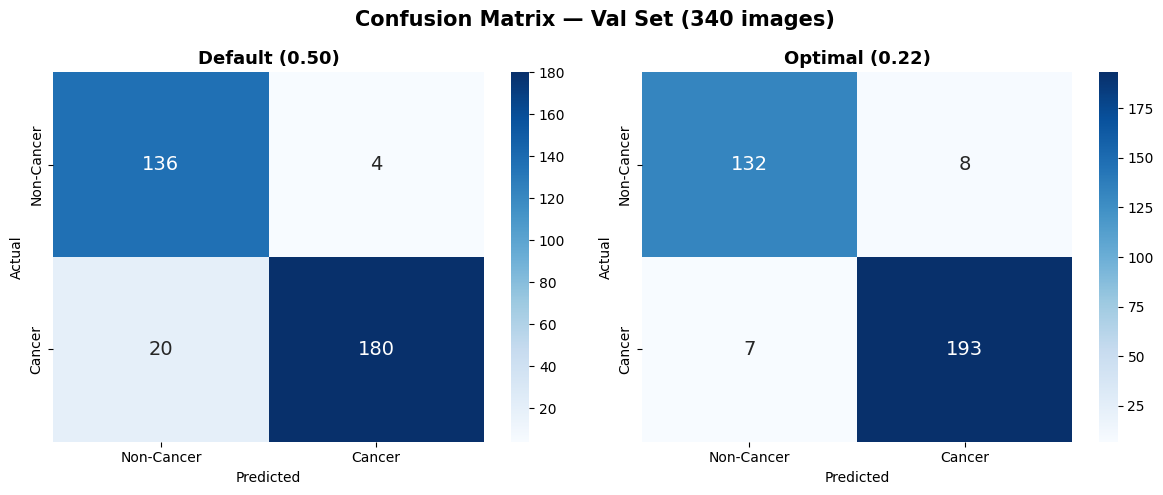

✅ Saved → /content/val_confusion_matrix.png


In [ ]:
# ── Confusion Matrices ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    ['Default (0.50)', f'Optimal ({best_thresh:.2f})']
):
    cm = confusion_matrix(y_val_final, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Cancer', 'Cancer'],
                yticklabels=['Non-Cancer', 'Cancer'],
                annot_kws={'size': 14})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle(f'Confusion Matrix — Val Set ({len(y_val_final)} images)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/val_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved → /content/val_confusion_matrix.png")

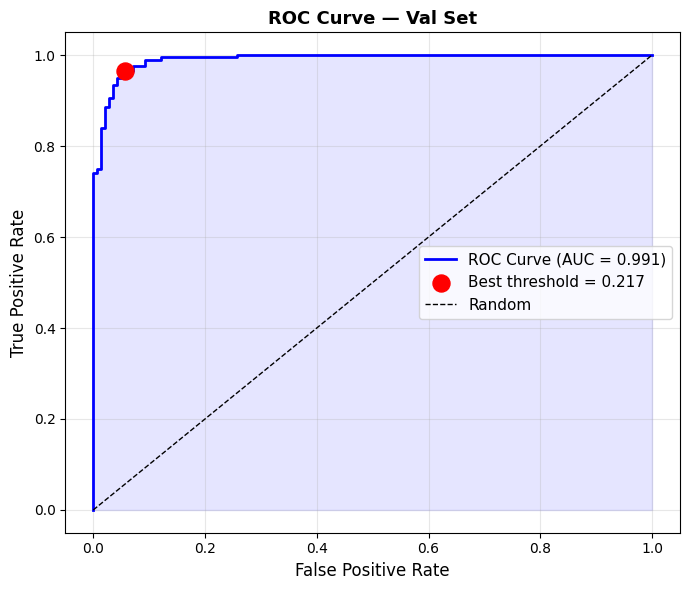

✅ Saved → /content/val_roc_curve.png


In [ ]:
# ── ROC Curve ──────────────────────────────────────
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx],
            color='red', s=150, zorder=5,
            label=f'Best threshold = {best_thresh:.3f}')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Val Set', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/val_roc_curve.png', dpi=150)
plt.show()
print("✅ Saved → /content/val_roc_curve.png")

In [ ]:
# ── Save Results CSV ───────────────────────────────
results_df = pd.DataFrame({
    'filepath'         : val_paths_final,
    'filename'         : [os.path.basename(f)
                          for f in val_paths_final],
    'actual'           : ['cancer' if y==1 else 'non_cancer'
                          for y in y_val_final],
    'predicted_default': ['cancer' if y==1 else 'non_cancer'
                          for y in y_pred_default],
    'predicted_optimal': ['cancer' if y==1 else 'non_cancer'
                          for y in y_pred_optimal],
    'cancer_prob'      : np.round(y_pred_prob, 4),
    'correct_default'  : y_val_final == y_pred_default,
    'correct_optimal'  : y_val_final == y_pred_optimal,
    'result'           : ['✅ CORRECT' if c else '❌ WRONG'
                          for c in (y_val_final == y_pred_optimal)]
})

results_df.to_csv('/content/val_predictions.csv', index=False)
print("✅ Saved → /content/val_predictions.csv")
print(f"\nSample:")
print(results_df[['filename','actual','predicted_optimal',
                   'cancer_prob','result']].head(10).to_string())

✅ Saved → /content/val_predictions.csv

Sample:
   filename      actual predicted_optimal  cancer_prob     result
0  297.jpeg  non_cancer        non_cancer       0.0001  ✅ CORRECT
1  284.jpeg  non_cancer            cancer       0.8228    ❌ WRONG
2  397.jpeg      cancer            cancer       0.9945  ✅ CORRECT
3  309.jpeg      cancer            cancer       0.9554  ✅ CORRECT
4  159.jpeg      cancer            cancer       0.9695  ✅ CORRECT
5  296.jpeg  non_cancer        non_cancer       0.1650  ✅ CORRECT
6  429.jpeg      cancer            cancer       0.9992  ✅ CORRECT
7  092.jpeg      cancer            cancer       0.9813  ✅ CORRECT
8  463.jpeg      cancer            cancer       0.9977  ✅ CORRECT
9  165.jpeg      cancer            cancer       0.9929  ✅ CORRECT


In [ ]:
# ── Count Correct & Wrong from CSV ────────────────
results_df = pd.read_csv('/content/val_predictions.csv')

total   = len(results_df)
correct = results_df['correct_optimal'].sum()
wrong   = total - correct

# Per class breakdown
cancer_df    = results_df[results_df['actual'] == 'cancer']
noncancer_df = results_df[results_df['actual'] == 'non_cancer']

cancer_correct    = cancer_df['correct_optimal'].sum()
cancer_wrong      = len(cancer_df) - cancer_correct
noncancer_correct = noncancer_df['correct_optimal'].sum()
noncancer_wrong   = len(noncancer_df) - noncancer_correct

print(f"\n{'='*45}")
print(f"      CSV PREDICTION COUNT SUMMARY")
print(f"{'='*45}")
print(f"  Total Images    : {total}")
print(f"  ─────────────────────────────────────")
print(f"  ✅ Correct       : {correct}  ({correct/total*100:.1f}%)")
print(f"  ❌ Wrong         : {wrong}   ({wrong/total*100:.1f}%)")
print(f"  ─────────────────────────────────────")
print(f"  Cancer     total : {len(cancer_df)}")
print(f"    ✅ Correct     : {cancer_correct}")
print(f"    ❌ Wrong       : {cancer_wrong}")
print(f"  Non-Cancer total : {len(noncancer_df)}")
print(f"    ✅ Correct     : {noncancer_correct}")
print(f"    ❌ Wrong       : {noncancer_wrong}")
print(f"{'='*45}")

# Also add count columns to csv and resave
results_df['count'] = 1
summary = results_df.groupby(['actual', 'result']).size().reset_index(name='count')
print(f"\nGrouped Summary:")
print(summary.to_string(index=False))


      CSV PREDICTION COUNT SUMMARY
  Total Images    : 340
  ─────────────────────────────────────
  ✅ Correct       : 325  (95.6%)
  ❌ Wrong         : 15   (4.4%)
  ─────────────────────────────────────
  Cancer     total : 200
    ✅ Correct     : 193
    ❌ Wrong       : 7
  Non-Cancer total : 140
    ✅ Correct     : 132
    ❌ Wrong       : 8

Grouped Summary:
    actual    result  count
    cancer ✅ CORRECT    193
    cancer   ❌ WRONG      7
non_cancer ✅ CORRECT    132
non_cancer   ❌ WRONG      8
